In [1]:
# === Cell 1: Configuration ===

import numpy as np

# Protein family paths (relative to this notebook)
DATA_DIR = "../Large Scale/bmDCA"
PF1 = "PF00004"
PF2 = "PF00041"

PARAMS_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_params.dat"
PARAMS_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_params.dat"
NAT_ENERGIES_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_naturalenergies.txt"
NAT_ENERGIES_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_naturalenergies.txt"

# Overlap length in nucleotides
OVERLAP_LEN = 62

# Random seed
SEED = 42

# Phase 1: Row-sweep RE
T1_RANGE = np.linspace(0.1, 1.5, 15)
T2_RANGE = np.linspace(0.1, 1.5, 15)
RE_ITERATIONS = 300_000
RE_SWAP_INTERVAL = 50
RE_SAVE_INTERVAL = 200
BURN_FRACTION = 0.3

# Phase 2: 2D RE zoom-in
ZOOM_GRID_SIZE = 6       # 6x6 = 36 replicas
ZOOM_PADDING = 2         # coarse grid spacings around optimum
RE2D_BURNIN = 200_000
RE2D_SAMPLES = 1000
RE2D_SAMPLE_INTERVAL = 200
RE2D_SWAP_INTERVAL = 50

In [2]:
# === Cell 2: Data Loading & JIT Warmup ===

import sys
import os
import time

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from overlappingGenes import (
    extract_params, load_natural_energies, initial_seq_no_stops,
    seq_str_to_int_array, mc_equilibrium_sampler,
    make_geometric_ladder, overlapped_sequence_generator_replica_exchange,
    run_replica_exchange, extract_per_temp_samples,
    re_2d_equilibrium_sampler, run_2d_replica_exchange
)

# Load DCA parameters
Js_1, hs_1 = extract_params(PARAMS_FILE_1)
Js_2, hs_2 = extract_params(PARAMS_FILE_2)

lenprot1 = len(hs_1) / 21
lenprot2 = len(hs_2) / 21
print(f"Protein 1 ({PF1}): {int(lenprot1)} AA, {int(3*lenprot1)} nt")
print(f"Protein 2 ({PF2}): {int(lenprot2)} AA, {int(3*lenprot2)} nt")
print(f"Overlap: {OVERLAP_LEN} nt")

DCA_params_1 = [Js_1, hs_1]
DCA_params_2 = [Js_2, hs_2]

# Load natural energies and compute stats
nat_energies_1 = np.array(load_natural_energies(NAT_ENERGIES_FILE_1))
nat_energies_2 = np.array(load_natural_energies(NAT_ENERGIES_FILE_2))
mean_1, std_1 = np.mean(nat_energies_1), np.std(nat_energies_1)
mean_2, std_2 = np.mean(nat_energies_2), np.std(nat_energies_2)
print(f"\nNatural energy stats:")
print(f"  {PF1}: mean={mean_1:.2f}, std={std_1:.2f} (n={len(nat_energies_1)})")
print(f"  {PF2}: mean={mean_2:.2f}, std={std_2:.2f} (n={len(nat_energies_2)})")

np.random.seed(SEED)

# --- JIT warmup: 1D RE (2 replicas, tiny run) ---
print("\nJIT warmup (1D RE)...")
t0 = time.time()
_ = run_replica_exchange(
    DCA_params_1, DCA_params_2,
    lenprot1, lenprot2, OVERLAP_LEN,
    n_replicas=2, n_iterations=100,
    swap_interval=10, save_interval=50,
    T1_ladder=np.array([0.5, 1.0]),
    T2_ladder=np.array([0.5, 1.0]),
    nat_std1=1.0, nat_std2=1.0
)
print(f"1D RE warmup done in {time.time() - t0:.1f}s")

# --- JIT warmup: 2D RE (2x2 grid, tiny run) ---
print("\nJIT warmup (2D RE)...")
t0 = time.time()
_ = run_2d_replica_exchange(
    DCA_params_1, DCA_params_2,
    lenprot1, lenprot2, OVERLAP_LEN,
    T1_grid=np.array([0.5, 1.0]),
    T2_grid=np.array([0.5, 1.0]),
    n_burnin=50, n_samples=5, sample_interval=10,
    swap_interval=10,
    nat_std1=1.0, nat_std2=1.0
)
print(f"2D RE warmup done in {time.time() - t0:.1f}s")

Protein 1 (PF00004): 110 AA, 330 nt
Protein 2 (PF00041): 74 AA, 222 nt
Overlap: 62 nt

Natural energy stats:
  PF00004: mean=145.88, std=38.25 (n=213960)
  PF00041: mean=120.66, std=17.64 (n=701132)

JIT warmup (1D RE)...
T1 ladder: [0.5 1. ]
T2 ladder: [0.5 1. ]
Replica exchange completed in 2.36 seconds.
Best energies: E1 = 437.0267, E2 = 292.4245
Swap acceptance rates: [0.]
1D RE warmup done in 4.2s

JIT warmup (2D RE)...
2D RE: 2x2 = 4 replicas
  T1 range: [0.500, 1.000]
  T2 range: [0.500, 1.000]
  Burn-in: 50, Samples: 5, Sample interval: 10, Swap interval: 10
2D RE completed in 1.28s (5 samples collected)
  Mean swap rate H: 0.500, V: 0.750
2D RE warmup done in 1.3s


In [3]:
# === Cell 3: Phase 1 — Row-sweep RE ===

from scipy.stats import ks_2samp, wasserstein_distance

n_T1 = len(T1_RANGE)
n_T2 = len(T2_RANGE)

# Metric grids
ks_grid = np.full((n_T2, n_T1), np.nan)
wass_grid = np.full((n_T2, n_T1), np.nan)
zscore_grid = np.full((n_T2, n_T1), np.nan)

print(f"Row-sweep RE: {n_T2} rows x {n_T1} T1 replicas")
print(f"RE per row: {RE_ITERATIONS} iterations, swap every {RE_SWAP_INTERVAL}, "
      f"save every {RE_SAVE_INTERVAL}")

t_start = time.time()

for row_idx, T2_val in enumerate(T2_RANGE):
    # Build ladders: T1 varies across replicas, T2 is constant
    T1_ladder = np.array(T1_RANGE, dtype=np.float64)
    T2_ladder = np.full(n_T1, T2_val, dtype=np.float64)

    result = run_replica_exchange(
        DCA_params_1, DCA_params_2,
        lenprot1, lenprot2, OVERLAP_LEN,
        n_replicas=n_T1,
        n_iterations=RE_ITERATIONS,
        swap_interval=RE_SWAP_INTERVAL,
        save_interval=RE_SAVE_INTERVAL,
        T1_ladder=T1_ladder,
        T2_ladder=T2_ladder,
        nat_std1=1.0, nat_std2=1.0,
    )

    # Extract per-temperature-rung samples
    E1_per_rung = extract_per_temp_samples(
        result['energy_history_1'], result['replica_index_history'],
        burn_fraction=BURN_FRACTION)
    E2_per_rung = extract_per_temp_samples(
        result['energy_history_2'], result['replica_index_history'],
        burn_fraction=BURN_FRACTION)

    # Compute metrics at each T1 rung
    for j in range(n_T1):
        e1_samp = E1_per_rung[j]
        e2_samp = E2_per_rung[j]
        # Remove NaNs if any
        valid = ~np.isnan(e1_samp) & ~np.isnan(e2_samp)
        e1_samp = e1_samp[valid]
        e2_samp = e2_samp[valid]
        if len(e1_samp) < 10:
            continue

        ks1 = ks_2samp(nat_energies_1, e1_samp).statistic
        ks2 = ks_2samp(nat_energies_2, e2_samp).statistic
        ks_grid[row_idx, j] = (ks1 + ks2) / 2

        w1 = wasserstein_distance(nat_energies_1, e1_samp)
        w2 = wasserstein_distance(nat_energies_2, e2_samp)
        wass_grid[row_idx, j] = (w1 + w2) / 2

        z1 = np.mean(np.abs((e1_samp - mean_1) / std_1))
        z2 = np.mean(np.abs((e2_samp - mean_2) / std_2))
        zscore_grid[row_idx, j] = z1 + z2

    elapsed = time.time() - t_start
    eta = elapsed / (row_idx + 1) * (n_T2 - row_idx - 1)
    swap_str = np.array2string(result['swap_rates'], precision=2)
    print(f"  Row {row_idx+1}/{n_T2} T2={T2_val:.3f} done "
          f"({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining) "
          f"swap_rates={swap_str}")

print(f"\nRow-sweep RE done in {time.time() - t_start:.0f}s")

Row-sweep RE: 15 rows x 15 T1 replicas
RE per row: 300000 iterations, swap every 50, save every 200
T1 ladder: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
T2 ladder: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Replica exchange completed in 3.38 seconds.
Best energies: E1 = 208.0773, E2 = 54.5882
Swap acceptance rates: [0.566 0.81  0.92  0.962 0.982 0.99  0.993 0.993 0.994 0.993 0.99  0.978
 0.953 0.9  ]
  Row 1/15 T2=0.100 done (7s elapsed, ~96s remaining) swap_rates=[0.57 0.81 0.92 0.96 0.98 0.99 0.99 0.99 0.99 0.99 0.99 0.98 0.95 0.9 ]
T1 ladder: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
T2 ladder: [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
Replica exchange completed in 3.39 seconds.
Best energies: E1 = 202.2907, E2 = 51.8695
Swap acceptance rates: [0.574 0.802 0.91  0.96  0.983 0.99  0.993 0.994 0.994 0.988 0.986 0.975
 0.946 0.901]
  Row 2/15 T2=0.200 done (14s elapsed, ~89s remaining) swap_rates=[0.57 0.8  

Best temperatures (coarse RE):
  KS:          T1=1.000, T2=0.800 (KS=0.4805)
  Wasserstein:  T1=0.600, T2=0.800 (W=29.55)
  Z-score:      T1=0.600, T2=0.800 (Z=1.947)


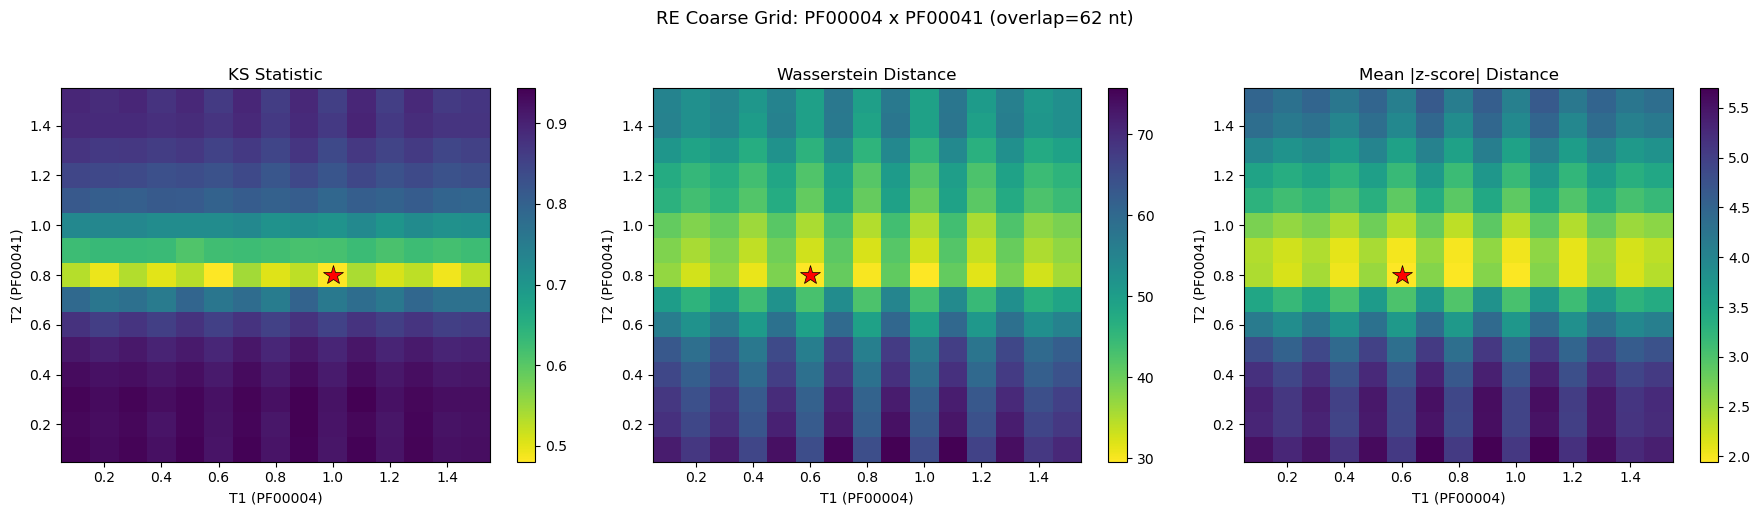

Saved re_coarse_heatmaps.png

Zoom region:
  T1: [0.400, 0.800]
  T2: [0.600, 1.000]


In [4]:
# === Cell 4: Heatmaps + Identify Zoom Region ===

import matplotlib.pyplot as plt

def find_best(grid, T1_range, T2_range):
    idx = np.nanargmin(grid)
    i, j = np.unravel_index(idx, grid.shape)
    return T2_range[i], T1_range[j], grid[i, j], i, j

best_ks_T2, best_ks_T1, best_ks_val, _, _ = find_best(ks_grid, T1_RANGE, T2_RANGE)
best_wass_T2, best_wass_T1, best_wass_val, wass_i, wass_j = find_best(wass_grid, T1_RANGE, T2_RANGE)
best_z_T2, best_z_T1, best_z_val, _, _ = find_best(zscore_grid, T1_RANGE, T2_RANGE)

print("Best temperatures (coarse RE):")
print(f"  KS:          T1={best_ks_T1:.3f}, T2={best_ks_T2:.3f} (KS={best_ks_val:.4f})")
print(f"  Wasserstein:  T1={best_wass_T1:.3f}, T2={best_wass_T2:.3f} (W={best_wass_val:.2f})")
print(f"  Z-score:      T1={best_z_T1:.3f}, T2={best_z_T2:.3f} (Z={best_z_val:.3f})")

# Plot heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

grids = [ks_grid, wass_grid, zscore_grid]
titles = ["KS Statistic", "Wasserstein Distance", "Mean |z-score| Distance"]
bests = [
    (best_ks_T1, best_ks_T2),
    (best_wass_T1, best_wass_T2),
    (best_z_T1, best_z_T2),
]

for ax, grid, title, (bT1, bT2) in zip(axes, grids, titles, bests):
    pcm = ax.pcolormesh(T1_RANGE, T2_RANGE, grid, cmap="viridis_r", shading="auto")
    ax.plot(bT1, bT2, "r*", markersize=15, markeredgecolor="k", markeredgewidth=0.5)
    ax.set_xlabel(f"T1 ({PF1})")
    ax.set_ylabel(f"T2 ({PF2})")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

fig.suptitle(f"RE Coarse Grid: {PF1} x {PF2} (overlap={OVERLAP_LEN} nt)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("re_coarse_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re_coarse_heatmaps.png")

# Define zoom region around Wasserstein optimum
T1_spacing = T1_RANGE[1] - T1_RANGE[0]
T2_spacing = T2_RANGE[1] - T2_RANGE[0]

zoom_T1_min = max(T1_RANGE[0], best_wass_T1 - ZOOM_PADDING * T1_spacing)
zoom_T1_max = min(T1_RANGE[-1], best_wass_T1 + ZOOM_PADDING * T1_spacing)
zoom_T2_min = max(T2_RANGE[0], best_wass_T2 - ZOOM_PADDING * T2_spacing)
zoom_T2_max = min(T2_RANGE[-1], best_wass_T2 + ZOOM_PADDING * T2_spacing)

print(f"\nZoom region:")
print(f"  T1: [{zoom_T1_min:.3f}, {zoom_T1_max:.3f}]")
print(f"  T2: [{zoom_T2_min:.3f}, {zoom_T2_max:.3f}]")

2D RE: 6x6 = 36 replicas
  T1 range: [0.400, 0.800]
  T2 range: [0.600, 1.000]
  Burn-in: 200000, Samples: 1000, Sample interval: 200, Swap interval: 50
2D RE completed in 11.07s (1000 samples collected)
  Mean swap rate H: 0.680, V: 0.789

Best temperatures (zoom 2D RE):
  KS:          T1=0.640, T2=1.000 (KS=0.4368)
  Wasserstein:  T1=0.400, T2=1.000 (W=19.89)
  Z-score:      T1=0.400, T2=0.920 (Z=1.110)


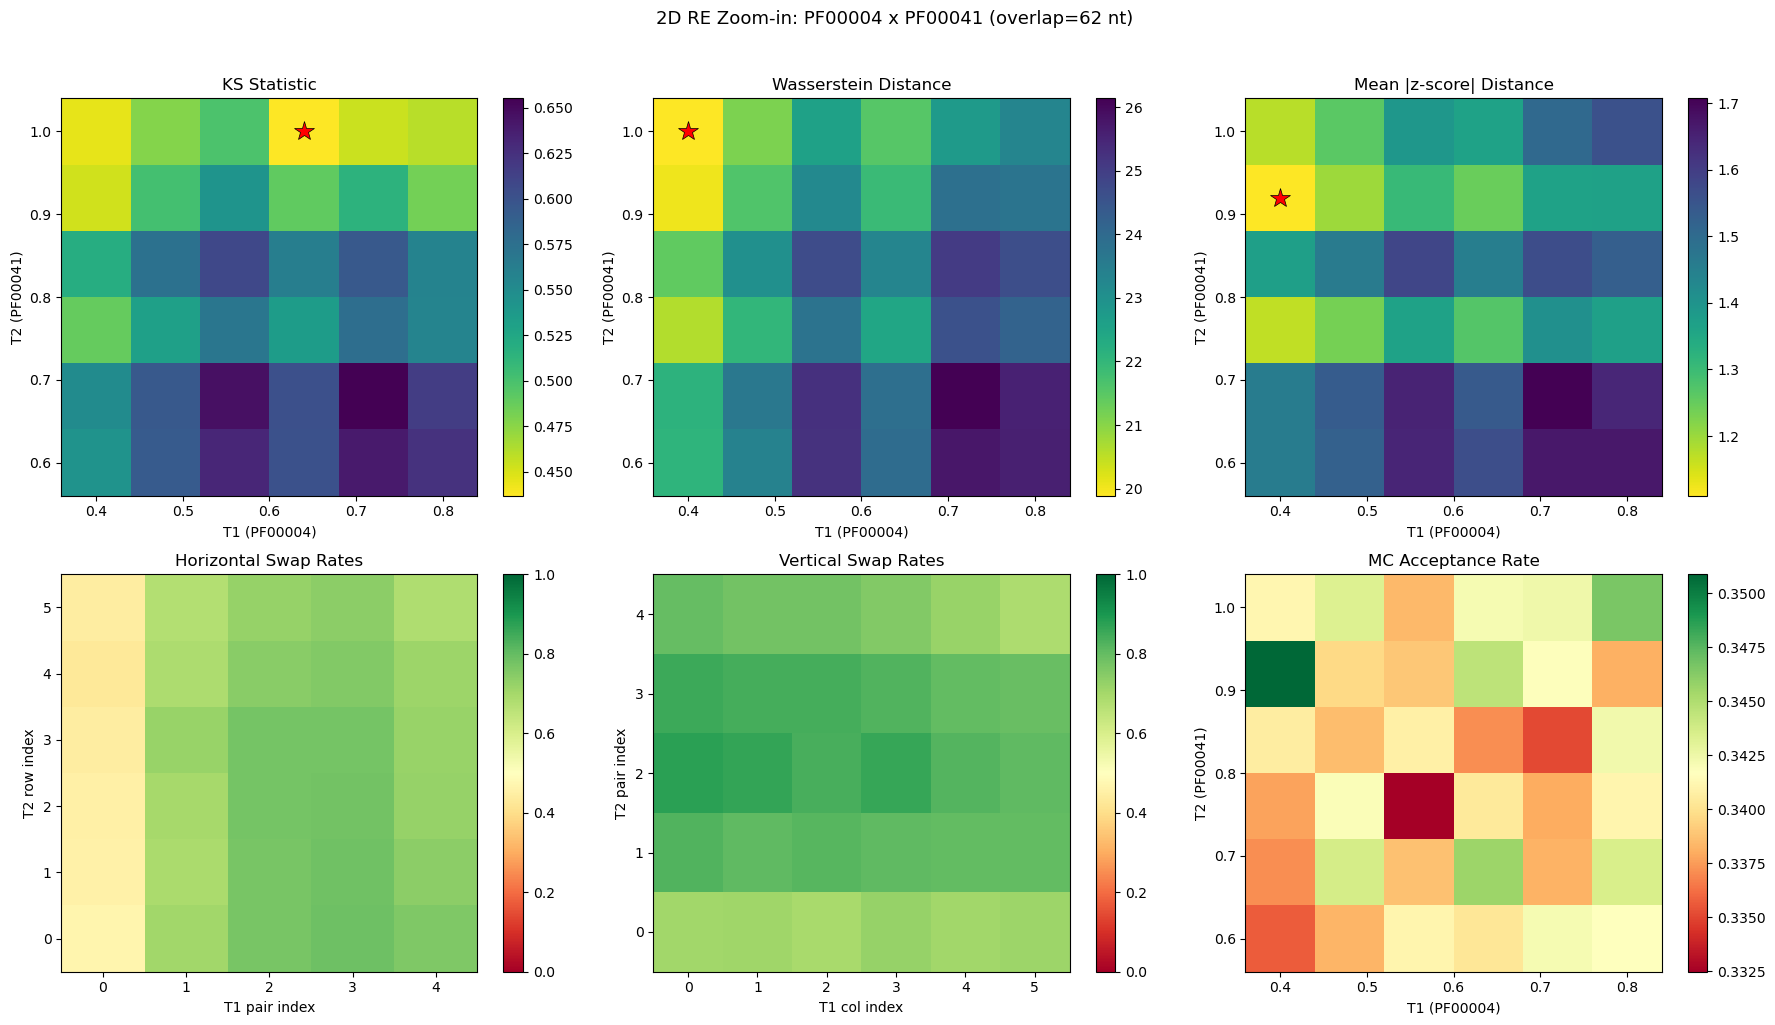

Saved re_zoom_heatmaps.png


In [5]:
# === Cell 5: Phase 2 — 2D RE Zoom-in ===

zoom_T1 = np.linspace(zoom_T1_min, zoom_T1_max, ZOOM_GRID_SIZE)
zoom_T2 = np.linspace(zoom_T2_min, zoom_T2_max, ZOOM_GRID_SIZE)

np.random.seed(SEED + 1)

result_2d = run_2d_replica_exchange(
    DCA_params_1, DCA_params_2,
    lenprot1, lenprot2, OVERLAP_LEN,
    T1_grid=zoom_T1, T2_grid=zoom_T2,
    n_burnin=RE2D_BURNIN, n_samples=RE2D_SAMPLES,
    sample_interval=RE2D_SAMPLE_INTERVAL,
    swap_interval=RE2D_SWAP_INTERVAL,
    nat_std1=1.0, nat_std2=1.0,
)

# Compute metrics on zoom grid
n_zT2 = len(zoom_T2)
n_zT1 = len(zoom_T1)
zoom_ks = np.full((n_zT2, n_zT1), np.nan)
zoom_wass = np.full((n_zT2, n_zT1), np.nan)
zoom_zscore = np.full((n_zT2, n_zT1), np.nan)

for i in range(n_zT2):
    for j in range(n_zT1):
        e1 = result_2d['E1_grid'][i, j]
        e2 = result_2d['E2_grid'][i, j]

        ks1 = ks_2samp(nat_energies_1, e1).statistic
        ks2 = ks_2samp(nat_energies_2, e2).statistic
        zoom_ks[i, j] = (ks1 + ks2) / 2

        w1 = wasserstein_distance(nat_energies_1, e1)
        w2 = wasserstein_distance(nat_energies_2, e2)
        zoom_wass[i, j] = (w1 + w2) / 2

        z1 = np.mean(np.abs((e1 - mean_1) / std_1))
        z2 = np.mean(np.abs((e2 - mean_2) / std_2))
        zoom_zscore[i, j] = z1 + z2

# Find best
z_best_wass_T2, z_best_wass_T1, z_best_wass_val, z_wi, z_wj = find_best(
    zoom_wass, zoom_T1, zoom_T2)
z_best_ks_T2, z_best_ks_T1, z_best_ks_val, _, _ = find_best(
    zoom_ks, zoom_T1, zoom_T2)
z_best_z_T2, z_best_z_T1, z_best_z_val, _, _ = find_best(
    zoom_zscore, zoom_T1, zoom_T2)

print(f"\nBest temperatures (zoom 2D RE):")
print(f"  KS:          T1={z_best_ks_T1:.3f}, T2={z_best_ks_T2:.3f} (KS={z_best_ks_val:.4f})")
print(f"  Wasserstein:  T1={z_best_wass_T1:.3f}, T2={z_best_wass_T2:.3f} (W={z_best_wass_val:.2f})")
print(f"  Z-score:      T1={z_best_z_T1:.3f}, T2={z_best_z_T2:.3f} (Z={z_best_z_val:.3f})")

# Plot zoom heatmaps + swap acceptance maps
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top row: metric heatmaps
for ax, grid, title, (bT1, bT2) in zip(
    axes[0],
    [zoom_ks, zoom_wass, zoom_zscore],
    ["KS Statistic", "Wasserstein Distance", "Mean |z-score| Distance"],
    [(z_best_ks_T1, z_best_ks_T2),
     (z_best_wass_T1, z_best_wass_T2),
     (z_best_z_T1, z_best_z_T2)]
):
    pcm = ax.pcolormesh(zoom_T1, zoom_T2, grid, cmap="viridis_r", shading="auto")
    ax.plot(bT1, bT2, "r*", markersize=15, markeredgecolor="k", markeredgewidth=0.5)
    ax.set_xlabel(f"T1 ({PF1})")
    ax.set_ylabel(f"T2 ({PF2})")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

# Bottom row: swap acceptance rates + MC acceptance
# Horizontal swap rates
ax = axes[1, 0]
pcm = ax.pcolormesh(np.arange(n_zT1 - 1), np.arange(n_zT2),
                    result_2d['swap_rates_h'], cmap="RdYlGn", vmin=0, vmax=1,
                    shading="auto")
ax.set_xlabel("T1 pair index")
ax.set_ylabel("T2 row index")
ax.set_title("Horizontal Swap Rates")
fig.colorbar(pcm, ax=ax)

# Vertical swap rates
ax = axes[1, 1]
pcm = ax.pcolormesh(np.arange(n_zT1), np.arange(n_zT2 - 1),
                    result_2d['swap_rates_v'], cmap="RdYlGn", vmin=0, vmax=1,
                    shading="auto")
ax.set_xlabel("T1 col index")
ax.set_ylabel("T2 pair index")
ax.set_title("Vertical Swap Rates")
fig.colorbar(pcm, ax=ax)

# MC acceptance rates
ax = axes[1, 2]
pcm = ax.pcolormesh(zoom_T1, zoom_T2, result_2d['acceptance_grid'],
                    cmap="RdYlGn", shading="auto")
ax.set_xlabel(f"T1 ({PF1})")
ax.set_ylabel(f"T2 ({PF2})")
ax.set_title("MC Acceptance Rate")
fig.colorbar(pcm, ax=ax)

fig.suptitle(f"2D RE Zoom-in: {PF1} x {PF2} (overlap={OVERLAP_LEN} nt)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("re_zoom_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re_zoom_heatmaps.png")

Best grid point: T1=0.400, T2=1.000
  1000 samples available


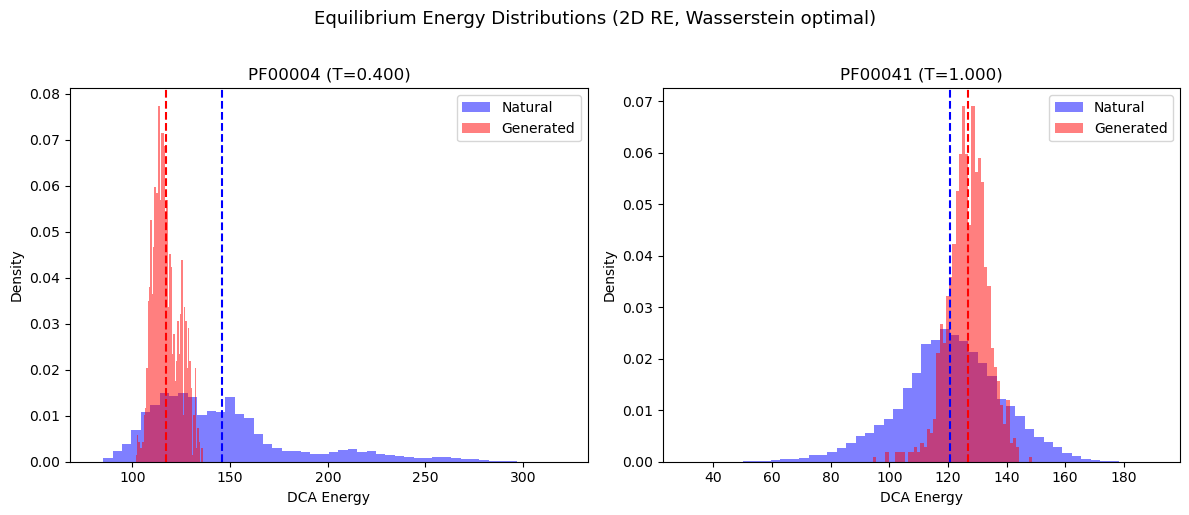

Saved re_energy_histograms.png


In [6]:
# === Cell 6: Energy Histograms at Best T ===

# Use best Wasserstein grid point from Phase 2
E1_best = result_2d['E1_grid'][z_wi, z_wj]
E2_best = result_2d['E2_grid'][z_wi, z_wj]

print(f"Best grid point: T1={z_best_wass_T1:.3f}, T2={z_best_wass_T2:.3f}")
print(f"  {len(E1_best)} samples available")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nat_e, gen_e, pf, mu, sd, T_val in [
    (axes[0], nat_energies_1, E1_best, PF1, mean_1, std_1, z_best_wass_T1),
    (axes[1], nat_energies_2, E2_best, PF2, mean_2, std_2, z_best_wass_T2),
]:
    ax.hist(nat_e, bins=50, density=True, alpha=0.5, color="blue", label="Natural")
    ax.hist(gen_e, bins=50, density=True, alpha=0.5, color="red", label="Generated")
    ax.axvline(np.mean(nat_e), color="blue", linestyle="--", linewidth=1.5)
    ax.axvline(np.mean(gen_e), color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("DCA Energy")
    ax.set_ylabel("Density")
    ax.set_title(f"{pf} (T={T_val:.3f})")
    ax.legend()

fig.suptitle(f"Equilibrium Energy Distributions (2D RE, Wasserstein optimal)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("re_energy_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re_energy_histograms.png")

<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
C:\Users\orson\AppData\Local\Temp\ipykernel_24368\213875975.py:49: SyntaxWarning: invalid escape sequence '\p'
  f"Samples within $\pm 1\sigma$ (both): {within_1sigma:.1f}%\n"


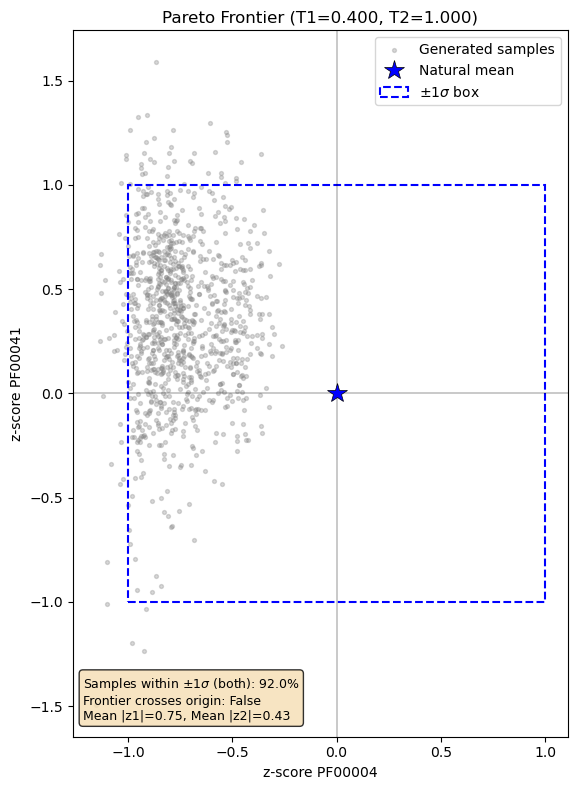

Saved re_pareto_frontier.png


In [7]:
# === Cell 7: Pareto Frontier ===

# Z-scores at best grid point
z1_det = (E1_best - mean_1) / std_1
z2_det = (E2_best - mean_2) / std_2

abs_z1 = np.abs(z1_det)
abs_z2 = np.abs(z2_det)

# Find Pareto frontier: non-dominated points in (|z1|, |z2|) space
sort_idx = np.argsort(abs_z1)
pareto_mask = np.zeros(len(z1_det), dtype=bool)
min_z2_so_far = np.inf
for k in sort_idx:
    if abs_z2[k] < min_z2_so_far:
        pareto_mask[k] = True
        min_z2_so_far = abs_z2[k]

pareto_abs_z1 = abs_z1[pareto_mask]
pareto_abs_z2 = abs_z2[pareto_mask]

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter all samples
ax.scatter(z1_det, z2_det, s=8, alpha=0.3, c="gray", label="Generated samples")

# Natural mean at origin
ax.plot(0, 0, "b*", markersize=15, markeredgecolor="k",
        markeredgewidth=0.5, zorder=5, label="Natural mean")

# +/- 1 sigma box
rect = plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor="blue",
                      linestyle="--", linewidth=1.5, label=r"$\pm 1\sigma$ box")
ax.add_patch(rect)

ax.set_xlabel(f"z-score {PF1}")
ax.set_ylabel(f"z-score {PF2}")
ax.set_title(f"Pareto Frontier (T1={z_best_wass_T1:.3f}, T2={z_best_wass_T2:.3f})")
ax.legend(loc="upper right")
ax.set_aspect("equal")
ax.axhline(0, color="k", linewidth=0.3)
ax.axvline(0, color="k", linewidth=0.3)

# Summary stats
within_1sigma = np.sum((abs_z1 <= 1) & (abs_z2 <= 1)) / len(z1_det) * 100
frontier_crosses = np.any((pareto_abs_z1 <= 0.1) & (pareto_abs_z2 <= 0.1))

stats_text = (
    f"Samples within $\pm 1\sigma$ (both): {within_1sigma:.1f}%\n"
    f"Frontier crosses origin: {frontier_crosses}\n"
    f"Mean |z1|={np.mean(abs_z1):.2f}, Mean |z2|={np.mean(abs_z2):.2f}"
)
ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment="bottom",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

fig.tight_layout()
fig.savefig("re_pareto_frontier.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re_pareto_frontier.png")